# Banking Customer Analysis

## Objective

The goal of this analysis is to understand the bank's customer base by analyzing demographic characteristics, income, credit scores and account information. The analysis is performed using Python and Pandas.

## 1. Data Loading and Initial Exploration

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
customers = pd.read_csv("../data/customers.csv")

customers.head()
customers.shape
customers.columns
customers.info()
customers.describe()

customers["city"].value_counts(normalize=True) *100

customers["monthly_income"].describe()

customers.sort_values(by= "monthly_income", ascending=False).head(10)

customers.groupby("city")["monthly_income"].mean().sort_values(ascending=False)

customers.groupby("city")["monthly_income"].agg(["mean", "min", "max"])

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        500 non-null    int64  
 1   first_name         500 non-null    str    
 2   last_name          500 non-null    str    
 3   date_of_birth      500 non-null    str    
 4   city               500 non-null    str    
 5   employment_status  500 non-null    str    
 6   monthly_income     500 non-null    float64
 7   credit_score       500 non-null    int64  
 8   customer_since     500 non-null    str    
 9   customer_status    500 non-null    str    
dtypes: float64(1), int64(2), str(7)
memory usage: 39.2 KB


,mean,min,max
city,,,
Belgrade,151981.584353,50666.31,247567.27
Kragujevac,156983.475532,50716.34,245299.93
Nis,156391.744224,51877.47,248678.73
Novi Sad,145299.445472,53710.35,246832.26
Valjevo,143770.217576,50450.57,248398.93


## 2. Customer Analysis

In [69]:
accounts = pd.read_csv("../data/accounts.csv")
loans = pd.read_csv("../data/loans.csv")
branches = pd.read_csv("../data/branches.csv")
transactions = pd.read_csv("../data/transactions.csv")

print(accounts.shape)
print(loans.shape)
print(branches.shape)
print(transactions.shape)

customer_accounts= customers.merge(
    accounts,
    on="customer_id",
    how="inner"
)

customer_accounts.head()

customer_accounts.shape

customer_balance= (customer_accounts.groupby(["customer_id", "first_name", "last_name"])["balance"].sum().sort_values(ascending=False))
customer_balance.head(10)

customer_summary= (customer_accounts.groupby(["customer_id", "first_name", "last_name"]).agg(
    number_of_accounts= ("account_id", "count"),
    total_balance= ("balance", "sum"),
    average_balance= ("balance", "mean")
    ).sort_values("total_balance", ascending=False))


account_branches = accounts.merge(
    branches,
    on="branch_id",
    how="inner"
)

branch_summary = (
    account_branches
    .groupby("branch_name")
    .agg(
        number_of_accounts=("account_id", "count"),
        total_balance=("balance", "sum"),
        average_balance=("balance", "mean")
    )
    .sort_values("total_balance", ascending=False)
)
branch_summary

loan_summary = (
    loans
    .groupby("loan_type")
    .agg(
        number_of_loans=("loan_id", "count"),
        total_principal=("principal_amount", "sum"),
        average_principal=("principal_amount", "mean"),
        average_interest_rate=("interest_rate", "mean")
    )
    .sort_values("total_principal", ascending=False)
)

loan_summary

transaction_summary = (
    transactions
    .groupby("transaction_type")
    .agg(
        number_of_transactions=("transaction_id", "count"),
        total_amount=("amount", "sum"),
        average_amount=("amount", "mean")
    )
    .sort_values("total_amount", ascending=False)
)
transaction_summary


transactions["transaction_direction"].value_counts()

transactions.groupby("transaction_direction")["amount"].sum()



(1500, 8)
(214, 11)
(25, 7)
(42000, 10)


transaction_direction
credit    1.352301e+09
debit     1.432121e+09
Name: amount, dtype: float64

In [70]:
average_income_city


,average_income,average_credit_score,number_of_customers
city,,,
Kragujevac,156983.475532,542.361702,94
Nis,156391.744224,598.206897,116
Belgrade,151981.584353,595.258824,85
Novi Sad,145299.445472,580.462264,106
Valjevo,143770.217576,579.323232,99


In [71]:
#How are customers distributed across cities?

city_distribution = (
    customers["city"].value_counts() .reset_index()

)

city_distribution


#Which cities have the highest average income?

average_income_city= (
    customers.groupby("city").agg(
        average_income=("monthly_income", "mean"),
        average_credit_score=("credit_score", "mean"),
        number_of_customers=("customer_id", "count")
    ).sort_values("average_income", ascending=False)

)

average_income_city


#Top 15 klijenata po prihodima

top_income= (customers.sort_values("monthly_income", ascending=False).head(15))

top_income


#Prosečan prihod po statusu zaposlenja

employment_income= (customers.groupby("employment_status").agg(
    average_income= ("monthly_income", "mean"),
    average_credit_score= ("credit_score", "mean"),
    customers= ("customer_id", "count")
   )
    .sort_values("average_income", ascending=False)
)

employment_income


#Najveći i najmanji credit score

customers.sort_values("credit_score", ascending=False).head(10)
customers.sort_values("credit_score").head(10)

,customer_id,first_name,last_name,date_of_birth,city,employment_status,monthly_income,credit_score,customer_since,customer_status
428,429,Stefan,Matic,2011-04-15,Nis,retired,184184.41,300,2020-10-15,active
330,331,Stefan,Rankovic,2010-02-06,Belgrade,self-employed,52473.25,301,2022-06-20,active
107,108,Mina,Matic,2008-03-27,Kragujevac,employed,156762.84,302,2018-09-17,active
246,247,Eleonora,Rankovic,2003-10-28,Valjevo,employed,227842.35,303,2021-01-23,active
2,3,Ana,Stanojevic,2011-02-17,Valjevo,retired,213853.76,308,2019-02-23,active
118,119,Mina,Matic,2000-03-16,Valjevo,employed,235534.36,308,2024-09-08,active
203,204,Eleonora,Sekulic,2001-12-26,Kragujevac,retired,235664.02,310,2024-09-27,active
451,452,Eleonora,Sekulic,2011-09-17,Novi Sad,self-employed,236797.29,313,2020-09-02,active
258,259,Eleonora,Sekulic,2005-07-03,Belgrade,self-employed,94986.79,313,2018-10-21,active
124,125,Eleonora,Rankovic,1997-11-26,Kragujevac,self-employed,196277.48,314,2019-10-06,active


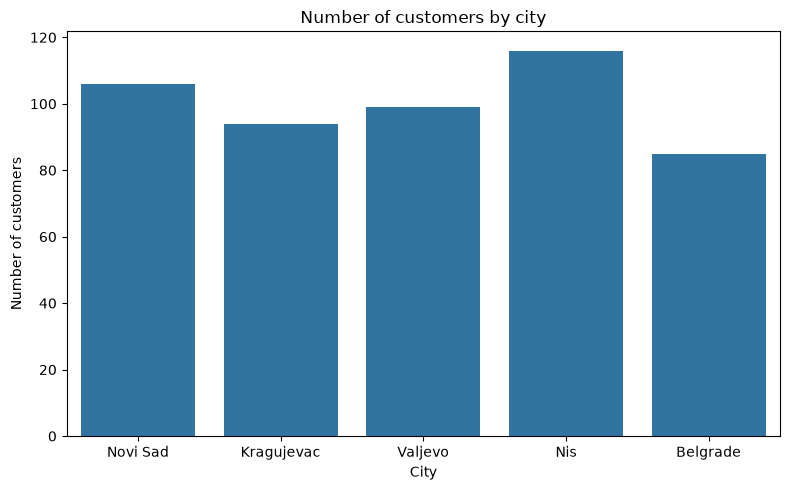

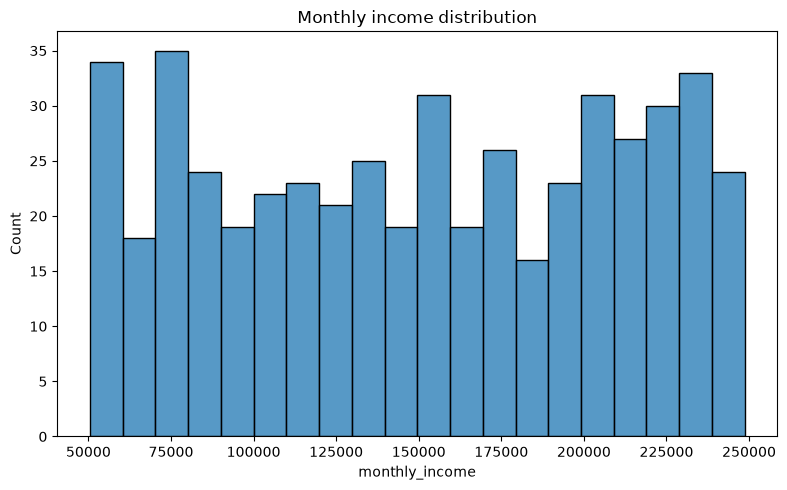

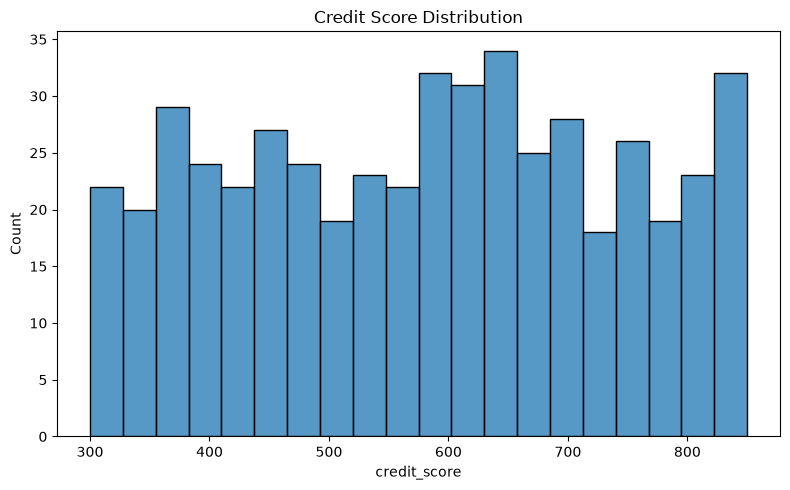

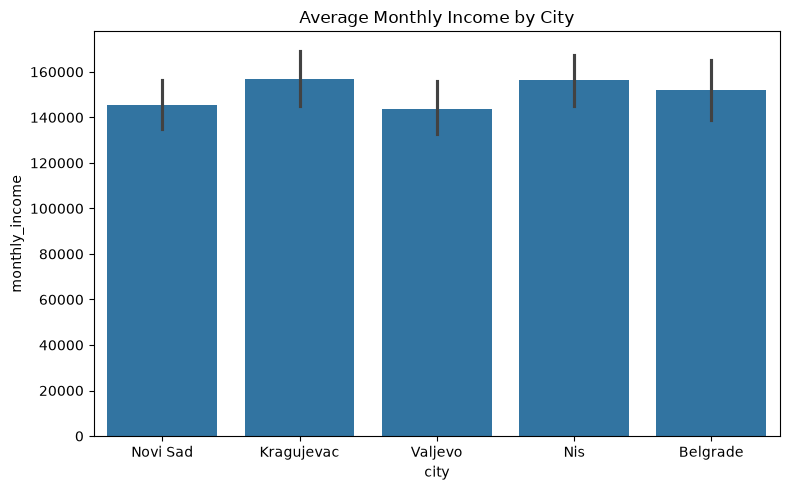

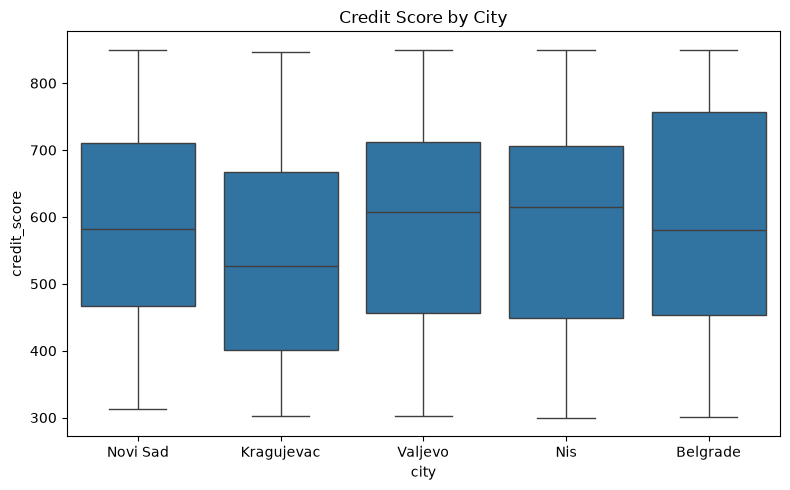

In [72]:


plt.figure(figsize=(8,5))

sns.countplot(data=customers, x="city")

plt.title("Number of customers by city")
plt.xlabel("City")
plt.ylabel("Number of customers")
plt.tight_layout()

plt.savefig("../images/number_of_customers_by_city.png", dpi=300)

plt.show()


plt.figure(figsize=(8,5))

sns.histplot(customers["monthly_income"], bins=20)

plt.title("Monthly income distribution")
plt.tight_layout()

plt.savefig("../images/income_distribution.png", dpi=300)

plt.show()


plt.figure(figsize=(8,5))

sns.histplot(
    customers["credit_score"],
    bins=20
)

plt.title("Credit Score Distribution")
plt.tight_layout()

plt.savefig("../images/credit_score_distribution.png", dpi=300)

plt.show()


plt.figure(figsize=(8,5))

sns.barplot(
    data=customers,
    x="city",
    y="monthly_income"
)

plt.title("Average Monthly Income by City")
plt.tight_layout()

plt.savefig("../images/income_by_city.png", dpi=300)

plt.show()


plt.figure(figsize=(8,5))

sns.boxplot(
    data=customers,
    x="city",
    y="credit_score"
)

plt.title("Credit Score by City")

plt.tight_layout()

plt.savefig("../images/credit_score_by_city.png", dpi=300)

plt.show()

# Business Insights

This section summarizes the main findings of the analysis and highlights the most important business insights.

## Customer Demographics

- The dataset contains 500 customers from five Serbian cities.
- Niš has the largest number of customers, while Belgrade has the smallest customer base.
- Customer income varies significantly, ranging from approximately 50,000 RSD to 249,000 RSD per month.

## Income Analysis

- Customers from Kragujevac have the highest average monthly income.
- Customers from Valjevo have the lowest average income among the analyzed cities.
- Higher income does not necessarily correspond to a higher average credit score.

## Customer Accounts

- New Belgrade branch manages the largest total account balance.
- Belgrade Center has the highest number of customer accounts.
- Average account balances are relatively similar across branches.

## Loan Portfolio

- Mortgage loans represent the largest share of the loan portfolio by total principal amount.
- Business and auto loans account for a considerably smaller share.
- Cash loans have the highest average interest rate.

## Transaction Analysis

- Salary payments generate the highest total transaction amount.
- Bank transfers represent the second largest transaction category.
- Debit transactions slightly exceed credit transactions in total value.

## Credit Scores

- Customer credit scores range from 300 to 850.
- Most customers have medium credit scores, indicating an average overall credit quality.

## Final Conclusion

This project demonstrates how Python and Pandas can be used to explore and analyze banking data. By combining information about customers, accounts, loans, and transactions, it was possible to identify useful patterns such as customer distribution, income differences between cities, account balances, loan structure, and transaction activity. Even though the dataset is relatively small, the project follows a workflow similar to a real-world data analysis and shows the basic skills required for data analytics projects.